# 06 — Predict Repeat Customers

## Objective

The objective of this notebook is to develop and evaluate machine learning models that predict whether a customer will make another purchase during a future period.

A time-based modeling approach will be used:

- Customer features will be created using transactions from an observation period.
- The prediction target will indicate whether each customer purchases again during a later prediction period.
- Logistic Regression, Random Forest, and XGBoost will be compared.
- Models will be evaluated using precision, recall, F1-score, ROC-AUC, and confusion matrices.

This approach prevents data leakage and reflects how a repeat-purchase prediction model would operate in a real business environment.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

In [2]:
customers = pd.read_csv(
    "../data/olist_customers_dataset.csv"
)

orders = pd.read_csv(
    "../data/olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp"]
)

order_items = pd.read_csv(
    "../data/olist_order_items_dataset.csv"
)

In [3]:
orders = orders[
    orders["order_status"] == "delivered"
].copy()

In [4]:
print(
    "Earliest purchase:",
    orders["order_purchase_timestamp"].min()
)

print(
    "Latest purchase:",
    orders["order_purchase_timestamp"].max()
)

Earliest purchase: 2016-09-15 12:16:38
Latest purchase: 2018-08-29 15:00:37


## Modeling Time Window

To prevent data leakage, customer features are calculated only from purchases made before the prediction period.

- **Observation period:** September 2016 – May 2018
- **Prediction period:** June 2018 – August 2018

Customers with purchase history during the observation period form the modeling population. A customer is labeled as a repeat customer if they make at least one additional purchase during the prediction period.

In [5]:
cutoff_date = pd.Timestamp("2018-06-01")
prediction_end = orders["order_purchase_timestamp"].max()

observation_orders = orders[
    orders["order_purchase_timestamp"] < cutoff_date
].copy()

future_orders = orders[
    (orders["order_purchase_timestamp"] >= cutoff_date) &
    (orders["order_purchase_timestamp"] <= prediction_end)
].copy()

print("Observation period:")
print(
    observation_orders["order_purchase_timestamp"].min(),
    "to",
    observation_orders["order_purchase_timestamp"].max()
)

print("\nPrediction period:")
print(
    future_orders["order_purchase_timestamp"].min(),
    "to",
    future_orders["order_purchase_timestamp"].max()
)

print("\nObservation orders:", len(observation_orders))
print("Prediction-period orders:", len(future_orders))

Observation period:
2016-09-15 12:16:38 to 2018-05-31 23:51:24

Prediction period:
2018-06-01 00:39:55 to 2018-08-29 15:00:37

Observation orders: 77869
Prediction-period orders: 18609


### Map Orders to Unique Customers

In [6]:
# Training Set
observation_orders = observation_orders.merge(
    customers[
        ["customer_id", "customer_unique_id"]
    ],
    on="customer_id",
    how="left"
)

# Test Set
future_orders = future_orders.merge(
    customers[
        ["customer_id", "customer_unique_id"]
    ],
    on="customer_id",
    how="left"
)

Now identify customers who purchase during the future period:

In [7]:
future_customers = set(
    future_orders["customer_unique_id"].dropna().unique()
)

### Create the Prediction Target
For every customer known before June 2018:

- 1 = customer purchased again during June–August 2018
- 0 = customer did not purchase again during that period

In [8]:
model_customers = (
    observation_orders[
        ["customer_unique_id"]
    ]
    .drop_duplicates()
    .copy()
)

model_customers["Repeat_Customer"] = (
    model_customers["customer_unique_id"]
    .isin(future_customers)
    .astype(int)
)

model_customers["Repeat_Customer"].value_counts()

Repeat_Customer
0    74968
1      419
Name: count, dtype: int64

In [9]:
model_customers["Repeat_Customer"].value_counts(
    normalize=True
).mul(100).round(2)

Repeat_Customer
0    99.44
1     0.56
Name: proportion, dtype: float64

## Customer Feature Engineering

Customer-level features are created using only transactions from the observation period to prevent information from the prediction period from entering the model.

The features capture three main dimensions of historical customer behavior:

- **Recency:** Days since the customer's most recent purchase
- **Frequency:** Number of completed orders
- **Monetary:** Total historical spending
- **Average Order Value:** Average spending per completed order
- **Customer Tenure:** Days since the customer's first observed purchase

### Calculate Order Values

In [10]:
order_revenue = (
    order_items
    .groupby("order_id", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "order_value"})
)

observation_transactions = observation_orders.merge(
    order_revenue,
    on="order_id",
    how="left"
)

### Create Customer Features (X)

In [11]:
customer_features = (
    observation_transactions
    .groupby("customer_unique_id")
    .agg(
        Frequency=("order_id", "nunique"),
        Monetary=("order_value", "sum"),
        Average_Order_Value=("order_value", "mean"),
        First_Purchase=("order_purchase_timestamp", "min"),
        Last_Purchase=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

customer_features["Recency"] = (
    cutoff_date - customer_features["Last_Purchase"]
).dt.days

customer_features["Customer_Tenure"] = (
    cutoff_date - customer_features["First_Purchase"]
).dt.days

### Add the Target (Y)

In [12]:
model_data = customer_features.merge(
    model_customers,
    on="customer_unique_id",
    how="inner"
)

model_data.head()

,customer_unique_id,Frequency,Monetary,Average_Order_Value,First_Purchase,Last_Purchase,Recency,Customer_Tenure,Repeat_Customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90,2018-05-10 10:56:27,2018-05-10 10:56:27,21,21,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90,2018-05-07 11:11:27,2018-05-07 11:11:27,24,24,0
2,0000f46a3911fa3c0805444483337064,1,69.00,69.00,2017-03-10 21:05:03,2017-03-10 21:05:03,447,447,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99,2017-10-12 20:29:41,2017-10-12 20:29:41,231,231,0
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00,2017-11-14 19:45:42,2017-11-14 19:45:42,198,198,0


In [13]:
print("Modeling customers:", len(model_data))

print("\nMissing values:")
print(
    model_data[
        [
            "Recency",
            "Frequency",
            "Monetary",
            "Average_Order_Value",
            "Customer_Tenure",
            "Repeat_Customer"
        ]
    ].isna().sum()
)

print("\nFeature summary:")
display(
    model_data[
        [
            "Recency",
            "Frequency",
            "Monetary",
            "Average_Order_Value",
            "Customer_Tenure"
        ]
    ].describe().round(2)
)

Modeling customers: 75387

Missing values:
Recency                0
Frequency              0
Monetary               0
Average_Order_Value    0
Customer_Tenure        0
Repeat_Customer        0
dtype: int64

Feature summary:


,Recency,Frequency,Monetary,Average_Order_Value,Customer_Tenure
count,75387.00,75387.00,75387.00,75387.00,75387.00
mean,194.68,1.03,141.39,137.36,196.81
std,132.05,0.21,213.39,207.66,132.50
min,0.00,1.00,0.85,0.85,0.00
25%,86.00,1.00,47.80,46.40,87.00
50%,177.00,1.00,89.70,87.00,179.00
75%,291.00,1.00,154.99,149.90,294.00
max,623.00,10.00,13440.00,13440.00,623.00


## Model Preparation

The engineered customer features are divided into training and test datasets for model development and evaluation.

Because repeat customers represent a very small proportion of the modeling population, stratified sampling is used to preserve the target class distribution in both datasets.

Customer identifiers and purchase dates are excluded from the model, as they are not predictive behavioral features.

### Define Features and Target

In [14]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Average_Order_Value",
    "Customer_Tenure"
]

X = model_data[features]
y = model_data["Repeat_Customer"]

Train/Test Split

We'll use 80% training / 20% testing.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (60309, 5)
Test set: (15078, 5)

Training target distribution:
Repeat_Customer
0    59974
1      335
Name: count, dtype: int64

Test target distribution:
Repeat_Customer
0    14994
1       84
Name: count, dtype: int64


### Scale Features for Logistic Regression

Logistic Regression is sensitive to differences in feature scale, so we'll standardize its inputs.

Random Forest and XGBoost will use the original values later because tree-based models don't require feature scaling.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

Logistic Regression is used as the baseline classification model.

Because repeat customers represent less than 1% of the dataset, balanced class weights are applied so that errors involving the minority repeat-customer class receive greater importance during training.

Model performance is evaluated primarily using precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

In [17]:
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [18]:
# Generate Predictions
log_pred = log_model.predict(X_test_scaled)

log_prob = log_model.predict_proba(
    X_test_scaled
)[:, 1]

In [19]:
# Evaluate the Model
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        log_pred,
        digits=3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, log_prob),
        3
    )
)

Classification Report:

              precision    recall  f1-score   support

           0      0.995     0.571     0.726     14994
           1      0.007     0.536     0.014        84

    accuracy                          0.571     15078
   macro avg      0.501     0.553     0.370     15078
weighted avg      0.990     0.571     0.722     15078

ROC-AUC: 0.578


In [20]:
cm = confusion_matrix(
    y_test,
    log_pred
)

cm

array([[8565, 6429],
       [  39,   45]], dtype=int64)

### Logistic Regression Results

The Logistic Regression model achieved a recall of 53.6% for repeat customers, meaning it identified slightly more than half of the customers who returned during the prediction period. However, precision was only 0.7%, indicating a very high number of false-positive predictions.

The ROC-AUC score of 0.578 suggests that the model has limited ability to distinguish repeat customers from non-repeat customers. Given the extreme class imbalance, accuracy is not considered a meaningful measure of model quality.

These results establish a baseline for comparison with more flexible classification models.

## Random Forest

Random Forest is evaluated as a nonlinear alternative to Logistic Regression. The model can capture more complex relationships and interactions between customer behavioral features.

Balanced class weights are retained because repeat customers remain highly underrepresented in the training data.

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [22]:
# Generate Predictions
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

In [23]:
# Evaluate
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        rf_pred,
        digits=3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, rf_prob),
        3
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        rf_pred
    )
)

Classification Report:

              precision    recall  f1-score   support

           0      0.994     0.994     0.994     14994
           1      0.011     0.012     0.011        84

    accuracy                          0.988     15078
   macro avg      0.503     0.503     0.503     15078
weighted avg      0.989     0.988     0.989     15078

ROC-AUC: 0.511

Confusion Matrix:
[[14901    93]
 [   83     1]]


### Random Forest Results

The Random Forest model achieved high overall accuracy but performed poorly on the minority repeat-customer class. It correctly identified only 1 of the 84 repeat customers in the test set, resulting in a recall of 1.2%.

Its ROC-AUC score of 0.511 is close to random classification and lower than the Logistic Regression baseline. This demonstrates why accuracy is misleading for this highly imbalanced prediction problem.

Overall, Random Forest did not improve repeat-customer identification.

### Add PR-AUC Before a Third Model

- There's one improvement I'd make to our evaluation plan now that we've seen the severity of the imbalance.

- With only 0.56% positives, PR-AUC (Average Precision) is more informative than ROC-AUC alone because it focuses on performance for the rare positive class.

- I don't want to mechanically add increasingly complicated models when the underlying signal may simply be weak. If both PR-AUC values are close to the 0.0056 baseline, that's evidence that these five historical features contain very little predictive information for a 90-day repeat purchase.

In [24]:
from sklearn.metrics import average_precision_score

In [25]:
log_pr_auc = average_precision_score(
    y_test,
    log_prob
)

rf_pr_auc = average_precision_score(
    y_test,
    rf_prob
)

print(
    "Logistic Regression PR-AUC:",
    round(log_pr_auc, 4)
)

print(
    "Random Forest PR-AUC:",
    round(rf_pr_auc, 4)
)

Logistic Regression PR-AUC: 0.0241
Random Forest PR-AUC: 0.0061


## Additional Behavioral Features

The initial models showed limited predictive performance, suggesting that basic RFM-style variables alone do not provide enough information to distinguish future repeat customers.

Additional features are therefore engineered from customers' historical purchases during the observation period:

- **Total Items:** Number of products purchased
- **Total Freight:** Total freight expenditure
- **Unique Products:** Number of distinct products purchased
- **Unique Sellers:** Number of distinct sellers purchased from

All features are calculated exclusively from transactions before the prediction cutoff to prevent data leakage.

In [26]:
behavior_features = (
    observation_orders[
        ["customer_unique_id", "order_id"]
    ]
    .merge(
        order_items[
            [
                "order_id",
                "product_id",
                "seller_id",
                "freight_value"
            ]
        ],
        on="order_id",
        how="left"
    )
    .groupby("customer_unique_id")
    .agg(
        Total_Items=("product_id", "count"),
        Total_Freight=("freight_value", "sum"),
        Unique_Products=("product_id", "nunique"),
        Unique_Sellers=("seller_id", "nunique")
    )
    .reset_index()
)

Merge them into the existing modeling dataset

In [27]:
model_data = model_data.merge(
    behavior_features,
    on="customer_unique_id",
    how="left"
)

In [28]:
new_features = [
    "Total_Items",
    "Total_Freight",
    "Unique_Products",
    "Unique_Sellers"
]

print("Missing values:")
print(model_data[new_features].isna().sum())

print("\nFeature summary:")
display(
    model_data[new_features]
    .describe()
    .round(2)
)

Missing values:
Total_Items        0
Total_Freight      0
Unique_Products    0
Unique_Sellers     0
dtype: int64

Feature summary:


,Total_Items,Total_Freight,Unique_Products,Unique_Sellers
count,75387.00,75387.00,75387.00,75387.00
mean,1.18,23.02,1.07,1.04
std,0.62,21.54,0.31,0.21
min,1.00,0.00,1.00,1.00
25%,1.00,14.08,1.00,1.00
50%,1.00,17.03,1.00,1.00
75%,1.00,25.18,1.00,1.00
max,21.00,1002.29,13.00,10.00


## Retrain Models with Expanded Features

In [29]:
features_expanded = [
    "Recency",
    "Frequency",
    "Monetary",
    "Average_Order_Value",
    "Customer_Tenure",
    "Total_Items",
    "Total_Freight",
    "Unique_Products",
    "Unique_Sellers"
]

X_expanded = model_data[features_expanded]
y = model_data["Repeat_Customer"]

In [30]:
X_train_expanded = X_expanded.loc[X_train.index]
X_test_expanded = X_expanded.loc[X_test.index]

In [31]:
print("Training set:", X_train_expanded.shape)
print("Test set:", X_test_expanded.shape)

Training set: (60309, 9)
Test set: (15078, 9)


In [32]:
# Scale Expanded features
scaler_expanded = StandardScaler()

X_train_expanded_scaled = scaler_expanded.fit_transform(
    X_train_expanded
)

X_test_expanded_scaled = scaler_expanded.transform(
    X_test_expanded
)

In [33]:
# Retrain Logistic Regression
log_model_expanded = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model_expanded.fit(
    X_train_expanded_scaled,
    y_train
)

log_pred_expanded = log_model_expanded.predict(
    X_test_expanded_scaled
)

log_prob_expanded = log_model_expanded.predict_proba(
    X_test_expanded_scaled
)[:, 1]

In [34]:
# Evaluate Logistic Regression Model 
print("Expanded Logistic Regression:\n")

print(
    classification_report(
        y_test,
        log_pred_expanded,
        digits=3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            log_prob_expanded
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            log_prob_expanded
        ),
        4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        log_pred_expanded
    )
)

Expanded Logistic Regression:

              precision    recall  f1-score   support

           0      0.996     0.594     0.744     14994
           1      0.007     0.536     0.014        84

    accuracy                          0.594     15078
   macro avg      0.501     0.565     0.379     15078
weighted avg      0.990     0.594     0.740     15078

ROC-AUC: 0.583
PR-AUC: 0.0247

Confusion Matrix:
[[8907 6087]
 [  39   45]]


In [35]:
# Retrain Random Forest
rf_model_expanded = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_expanded.fit(
    X_train_expanded,
    y_train
)

rf_pred_expanded = rf_model_expanded.predict(
    X_test_expanded
)

rf_prob_expanded = rf_model_expanded.predict_proba(
    X_test_expanded
)[:, 1]

In [36]:
# Evaluate Random Forest Model
print("Expanded Random Forest:\n")

print(
    classification_report(
        y_test,
        rf_pred_expanded,
        digits=3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            rf_prob_expanded
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            rf_prob_expanded
        ),
        4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        rf_pred_expanded
    )
)

Expanded Random Forest:

              precision    recall  f1-score   support

           0      0.994     0.999     0.997     14994
           1      0.043     0.012     0.019        84

    accuracy                          0.993     15078
   macro avg      0.519     0.505     0.508     15078
weighted avg      0.989     0.993     0.991     15078

ROC-AUC: 0.569
PR-AUC: 0.0103

Confusion Matrix:
[[14972    22]
 [   83     1]]


### Expanded Feature Results

Adding product, seller, item, and freight information produced modest improvements in predictive performance.

The expanded Logistic Regression model achieved the strongest overall results, with a ROC-AUC of 0.583 and PR-AUC of 0.0247. It identified 53.6% of actual repeat customers, although precision remained very low because of the extreme rarity of repeat purchases.

Random Forest improved substantially in ranking performance after adding the behavioral features, but it continued to identify only 1.2% of actual repeat customers at the default classification threshold.

Overall, the results suggest that richer transaction features provide some additional predictive information, but repeat purchasing remains difficult to predict from the available customer history.

## Model Comparison Table

In [37]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - Basic",
        "Random Forest - Basic",
        "Logistic Regression - Expanded",
        "Random Forest - Expanded"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, log_prob_expanded),
        roc_auc_score(y_test, rf_prob_expanded)
    ],
    "PR_AUC": [
        average_precision_score(y_test, log_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, log_prob_expanded),
        average_precision_score(y_test, rf_prob_expanded)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, log_pred_expanded),
        precision_score(y_test, rf_pred_expanded)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, log_pred_expanded),
        recall_score(y_test, rf_pred_expanded)
    ],
    "F1_Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, log_pred_expanded),
        f1_score(y_test, rf_pred_expanded)
    ]
})

model_comparison.round(4)

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1_Score
0,Logistic Regression - Basic,0.5779,0.0241,0.0070,0.5357,0.0137
1,Random Forest - Basic,0.5114,0.0061,0.0106,0.0119,0.0112
2,Logistic Regression - Expanded,0.5834,0.0247,0.0073,0.5357,0.0145
3,Random Forest - Expanded,0.5687,0.0103,0.0435,0.0119,0.0187


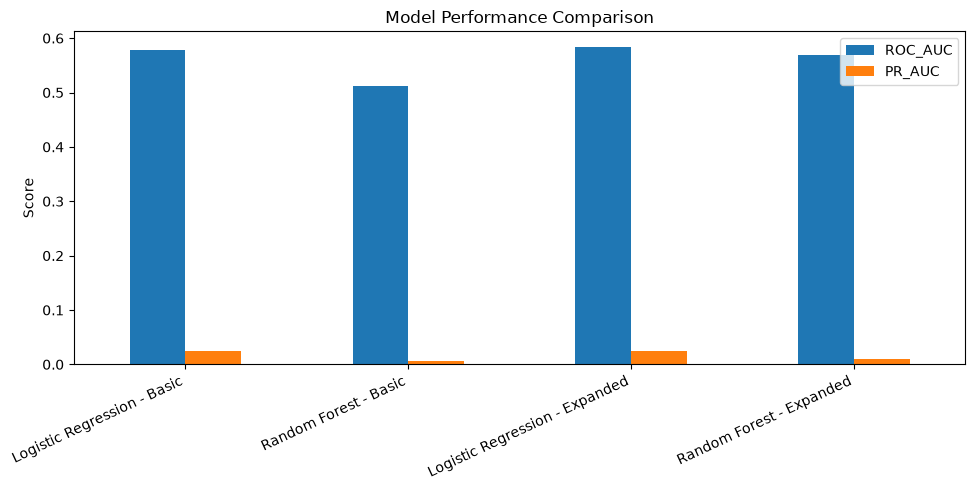

In [38]:
comparison_plot = (
    model_comparison
    .set_index("Model")[["ROC_AUC", "PR_AUC"]]
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Model Interpretation

The expanded Logistic Regression model was selected for interpretation because it provided the strongest overall ranking performance while identifying a substantially larger proportion of repeat customers than Random Forest.

Since the model was trained using standardized features, its coefficients can be compared to understand which customer behaviors are most strongly associated with future repeat purchasing.

In [39]:
# Extract Coefficents
feature_importance = pd.DataFrame({
    "Feature": features_expanded,
    "Coefficient": log_model_expanded.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = (
    feature_importance
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
0,Recency,-0.895284,0.895284
1,Customer_Tenure,0.620271,0.620271
2,Total_Items,0.259473,0.259473
3,Total_Freight,-0.146003,0.146003
4,Average_Order_Value,-0.099887,0.099887
5,Monetary,-0.074545,0.074545
6,Unique_Sellers,0.067917,0.067917
7,Unique_Products,-0.049862,0.049862
8,Frequency,0.026689,0.026689


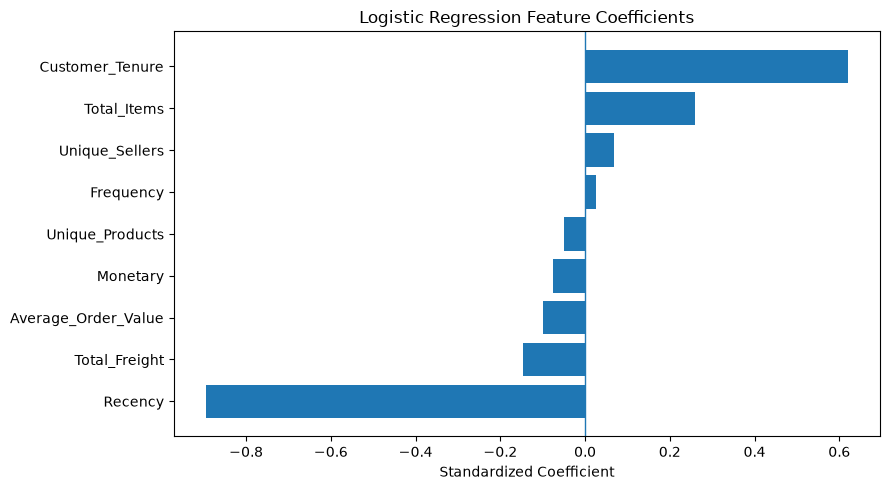

In [44]:
plot_data = (
    feature_importance
    .sort_values("Coefficient")
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title(
    "Logistic Regression Feature Coefficients"
)

plt.xlabel("Standardized Coefficient")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Feature Importance Insights

Recency was the strongest predictor of future repeat purchasing. Customers whose most recent purchase occurred further in the past were less likely to purchase during the prediction period, highlighting the importance of recent customer engagement.

Customer tenure was the second strongest predictor, with longer-established customers showing a greater likelihood of returning. The number of items purchased also showed a positive association with future repeat purchasing.

Higher freight expenditure was negatively associated with repeat-purchase likelihood, although its effect was considerably smaller than recency and tenure.

Overall, the model suggests that **customer recency and relationship history are more informative for repeat-purchase prediction than spending value alone**. These relationships represent predictive associations and should not be interpreted as causal effects.

## Save Model Predictions

In [45]:
customer_predictions = model_data.loc[
    X_test_expanded.index,
    ["customer_unique_id"]
].copy()

customer_predictions["Actual_Repeat"] = y_test

customer_predictions["Predicted_Probability"] = (
    log_prob_expanded
)

customer_predictions["Predicted_Repeat"] = (
    log_pred_expanded
)

customer_predictions = (
    customer_predictions
    .sort_values(
        "Predicted_Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

customer_predictions.head(10)

,customer_unique_id,Actual_Repeat,Predicted_Probability,Predicted_Repeat
0,8d50f5eadf50201ccdcedfb9e2ac8455,1,0.998441,1
1,698e1cf81d01a3d389d96145f7fa6df8,0,0.986701,1
2,a3dc27d87234f862d7e61a0148c77fa9,0,0.985480,1
3,8dc4412f2ddf5ffee6cf50e6278b37fd,0,0.985472,1
4,310647380793836bfa5b7b6b3f518423,0,0.983867,1
5,12d8b5ed661190a3a08183644dfc504d,0,0.979785,1
6,a1874c5550d2f0bc14cc122164603713,0,0.979200,1
7,47c1a3033b8b77b3ab6e109eb4d5fdf3,0,0.977121,1
8,041caba6a63ace5818387698ea85cdb2,0,0.974556,1
9,b39dde6dd619943190a8cc9aa6db38a4,0,0.955228,1


In [46]:
print(
    "Customers:",
    len(customer_predictions)
)

print(
    "Actual repeat customers:",
    customer_predictions["Actual_Repeat"].sum()
)

print(
    "Predicted repeat customers:",
    customer_predictions["Predicted_Repeat"].sum()
)

customer_predictions[
    "Predicted_Probability"
].describe().round(3)

Customers: 15078
Actual repeat customers: 84
Predicted repeat customers: 6132


count    15078.000
mean         0.474
std          0.098
min          0.014
25%          0.412
50%          0.481
75%          0.533
max          0.998
Name: Predicted_Probability, dtype: float64

In [47]:
customer_predictions = customer_predictions.rename(
    columns={
        "Predicted_Probability": "Repeat_Propensity_Score"
    }
)

In [48]:
customer_predictions.to_csv(
    "../outputs/customer_predictions.csv",
    index=False
)

In [49]:
model_comparison.to_csv(
    "../outputs/model_performance.csv",
    index=False
)

## Saved Outputs

The final customer-level prediction scores and model performance results were saved for downstream analysis and dashboard development.

- `customer_predictions.csv` contains actual repeat-purchase outcomes, model propensity scores, and binary predictions for test customers.
- `model_performance.csv` contains evaluation metrics for the baseline and expanded models.

Because balanced class weights were used during model training, the propensity scores are primarily intended for **customer ranking rather than direct probability interpretation**.

## Business Recommendations

The predictive analysis highlights several opportunities for improving customer retention:

- **Prioritize recently active customers:** Recency was the strongest predictor of future repeat purchasing. Retention campaigns should therefore engage customers while their relationship with the marketplace is still recent.

- **Strengthen relationships with established customers:** Longer-tenure customers showed a greater likelihood of returning, suggesting that maintaining engagement with existing customers can support repeat purchasing.

- **Encourage broader purchasing behavior:** Customers purchasing more items showed a stronger association with future repeat purchases. Cross-selling and personalized product recommendations may help increase engagement.

- **Review the impact of freight costs:** Higher freight expenditure was negatively associated with repeat-purchase likelihood, suggesting that shipping costs may be relevant when designing retention offers.

- **Use model scores for prioritization:** Given the extreme class imbalance and low precision, the model should not be used as an automatic repeat-customer classifier. Instead, propensity scores can help rank customers for targeted retention campaigns, ideally combined with business rules and campaign testing.

## Conclusion

This notebook developed a leakage-safe machine learning framework for predicting future repeat purchasing using customer behavior observed before a defined prediction period.

Repeat purchasing proved to be an extremely rare event, representing only 0.56% of the modeling population. Logistic Regression and Random Forest models were evaluated using both basic and expanded behavioral features.

The expanded Logistic Regression model provided the strongest overall performance, achieving a ROC-AUC of 0.583 and PR-AUC of 0.0247 while identifying 53.6% of actual repeat customers. However, its low precision demonstrates that repeat purchasing remains difficult to predict reliably from the available transaction history.

Model interpretation showed that recency and customer tenure were the strongest predictors of future purchasing behavior. Rather than using the model as an automatic classifier, its scores are better suited to ranking customers for targeted retention initiatives.

Overall, the analysis demonstrates both the potential and limitations of predictive customer analytics in a marketplace with very low repeat-purchase behavior.